### 16 数据可视化

In [7]:
from pathlib import Path
import csv
from datetime import datetime
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.unicode_minus'] = False

path = Path("/Users/summer/PycharmProjects/LearningPython/pythonScratch/dataset/weather_data/sitka_weather_2021_simple.csv")
lines = path.read_text().splitlines()

reader = csv.reader(lines)
header_now = next(reader)
print(header_now)

['STATION', 'NAME', 'DATE', 'TAVG', 'TMAX', 'TMIN']


In [8]:
low_temps, high_temps, dates = [], [], []
for row in reader:
    high_temps.append(int(row[4]))
    low_temps.append(int(row[5]))
    dates.append(datetime.strptime(row[2], '%Y-%m-%d'))

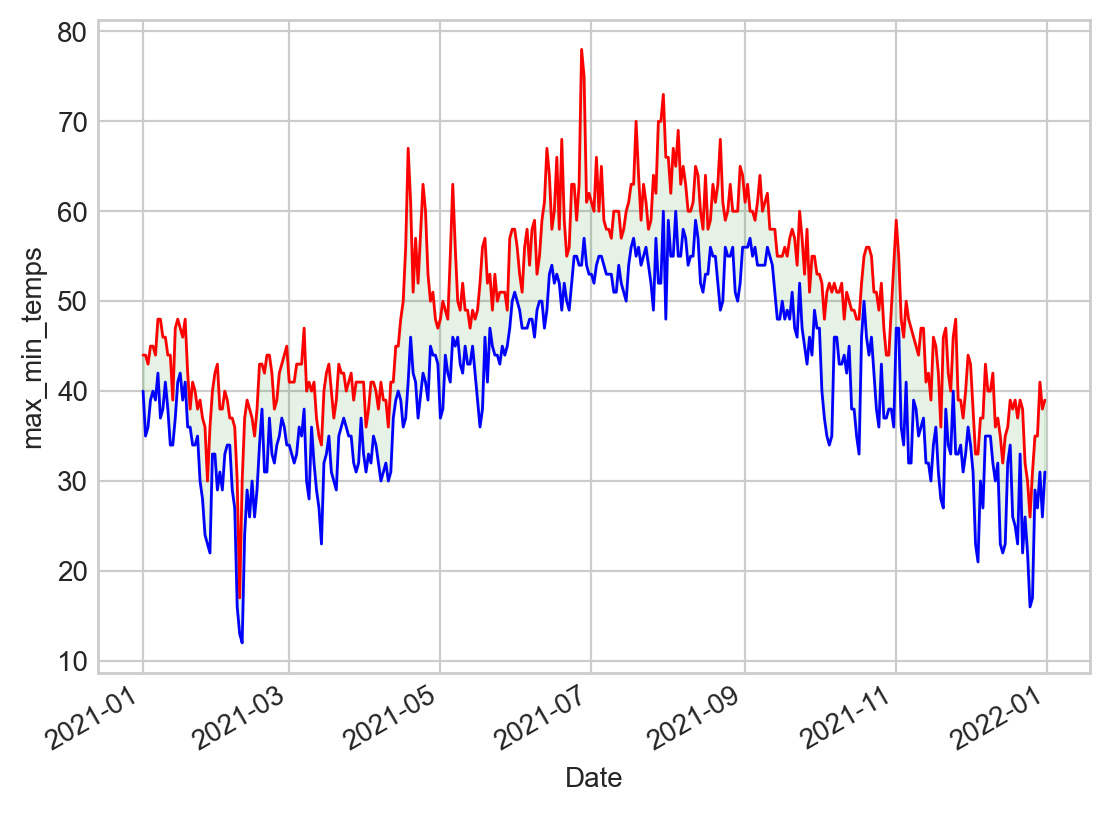

In [9]:
import matplotlib.pyplot as plt
plt.style.available
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots()
ax.plot(dates, high_temps, color='red', linewidth=1)
ax.plot(dates, low_temps, color='blue', linewidth=1)
fig.autofmt_xdate()
ax.set_xlabel("Date")
ax.set_ylabel("max_min_temps")
ax.fill_between(dates, low_temps, high_temps,  color='green', alpha=0.1)
plt.show()

#### 地震数据可视化

In [40]:
from pathlib import Path
import json

path = Path("/Users/summer/PycharmProjects/LearningPython/pythonScratch/dataset/earth_data/eq_data_30_day_m1.geojson")
lines = path.read_text()

In [41]:
# 将数据格式化
contents = json.loads(lines)
export_path = Path("readable_eq_date.geojson")
readable_contents = json.dumps(contents, indent=4)
export_path.write_text(readable_contents)

8863057

In [42]:
# 创建地震列表
path = Path("readable_eq_date.geojson")
lines = path.read_text()
contents = json.loads(lines)
all_eq_dicts = contents['features']
print(len(all_eq_dicts))

6359


In [43]:
# 提取震级
mags = []
for eq_dict in all_eq_dicts:
    mag = eq_dict['properties']['mag']
    mags.append(mag)
print(mags[:10])

[1.6, 1.6, 2.2, 3.7, 2.92000008, 1.4, 4.6, 4.5, 1.9, 1.8]


In [ ]:
# 提取经纬度
mags, titles, longitudes, latitudes, eq_titles = [], [], [], [], []
for eq_dict in all_eq_dicts:
    mag = eq_dict['properties']['mag']
    title = eq_dict['properties']['title']
    longitude = eq_dict['geometry']['coordinates'][0]
    latitude = eq_dict['geometry']['coordinates'][1]
    mags.append(mag)
    titles.append(title)
    longitudes.append(longitude)
    latitudes.append(latitude)
print(mags[:5])
print(titles[:5])
print(longitudes[:5])
print(latitudes[:5])

[1.6, 1.6, 2.2, 3.7, 2.92000008]
['M 1.6 - 27 km NNW of Susitna, Alaska', 'M 1.6 - 63 km SE of Pedro Bay, Alaska', 'M 2.2 - 27 km SSE of Cantwell, Alaska', 'M 3.7 - south of Alaska', 'M 2.9 - 49 km SE of Naalehu, Hawaii']
[-150.7585, -153.4716, -148.7531, -159.6267, -155.248336791992]
[61.7591, 59.3152, 63.1633, 54.5612, 18.7551670074463]


In [45]:
# 绘制经纬度散点图
import plotly.express as px
fig = px.scatter(x=longitudes,
                 y=latitudes,
                 labels={'x': 'longitude', 'y': 'latitude'},
                 range_x=[-200, 200],
                 range_y=[-90, 90],
                 width=800,
                 height=800,
                 title='Global Earthquakes',)
fig.write_html('global_earthquake_map.html')
fig.show()

In [51]:
# 使用世界地图显示地震分布,并使用震级标注大小
import plotly.express as px
fig = px.scatter_geo(lat=latitudes,
                     lon=longitudes,
                     title='Global Earthquakes',
                     size=mags,
                     color=mags,
                     size_max=10,
                     hover_name=titles,
                     )
fig.show()